In [1]:
# Import thư viện
import numpy as np
import pandas as pd
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    auc,
    precision_recall_curve,
    recall_score,
    precision_score,
)
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
import matplotlib.pyplot as plt
import joblib

In [2]:
# Nạp dữ liệu đã tiền xử lý
data = np.load(r"D:\maihoaa\SIC hè 2026\Project\Notebook\credit_card_processed.npz")
X_train = data["X_train"]
y_train = data["y_train"]
X_test = data["X_test"]
y_test = data["y_test"]

# 1. Xây dựng mô hình baseline

In [3]:
# Tính tỉ lệ chêch lệch Class của tập Train
scale_pos_weight_val = np.sum(y_train == 0) / np.sum(y_train == 1)

# Xây dựng Baseline
xgb_baseline = XGBClassifier(
    n_estimators = 100,
    max_depth = 6,
    learning_rate = 0.1,
    scale_pos_weight = scale_pos_weight_val,
    random_state = 2,
    n_jobs = -1,
    eval_metric = "logloss")
xgb_baseline.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [4]:
# Đánh giá trên tập Test
y_pred_baseline = xgb_baseline.predict(X_test)

recall_base = recall_score(y_test, y_pred_baseline)
f1_base = f1_score(y_test, y_pred_baseline)
cm_base = confusion_matrix(y_test, y_pred_baseline)

print(f"Recall : {recall_base * 100:.2f}%")
print(f"F1-Score : {f1_base:.4f}")
print("\nMa trận nhầm lẫn (Confusion Matrix):")
print(f"TN     : {cm_base[0][0]:<6} | FP     : {cm_base[0][1]}")
print(f"FN     : {cm_base[1][0]:<6} | TP     : {cm_base[1][1]}")

Recall : 80.00%
F1-Score : 0.7755

Ma trận nhầm lẫn (Confusion Matrix):
TN     : 56626  | FP     : 25
FN     : 19     | TP     : 76


F1-Score = 0.7755 => Mô hình tương đối tốt, XGBoost tương thích tốt với bài toán

# 2. Tối ưu mô hình và điều chỉnh siêu tham số (Hyperparameter Tuning)

## 2.1 Cấu hình Validation và không gian tìm kiếm tham số

In [5]:
# Chia tập train thành 5 phần (vẫn giữ nguyên tỉ lệ Class)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Khai báo các khoảng giá trị
param_grid = {
    "n_estimators": [100, 150, 200, 250],
    "max_depth": [3, 4, 5, 6, 7],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],  
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [
        0.7,
        0.8,
        0.9,
        1.0,
    ],
    "gamma": [0, 0.1, 0.2, 0.5],
}

## 2.2 Khởi tạo và chạy RandomizedSearchCV

In [6]:
# Cấu hình công cụ tìm kiếm ngẫu nhiên 10 bộ tham số tốt nhất
xgb_search = RandomizedSearchCV(
    estimator=xgb_baseline,
    param_distributions=param_grid,
    n_iter=10,
    scoring="f1",
    cv=cv,
    verbose=1,
    random_state=2,
    n_jobs=-1,
)

# Tiến hành chạy tìm kiếm trên toàn bộ dữ liệu huấn luyện
xgb_search.fit(X_train, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.7, 0.8, ...], 'gamma': [0, 0.1, ...], 'learning_rate': [0.01, 0.03, ...], 'max_depth': [3, 4, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",2
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set 

## 2.3 Kết quả mô hình tốt nhất

In [7]:
print(f"F1-Score trung bình tốt nhất: {xgb_search.best_score_:.4f}")
print("\nBộ siêu tham số tối ưu:")
for param, value in xgb_search.best_params_.items():
    print(f"    - {param}: {value}")

# Lưu lại mô hình có hiệu suất tốt nhất để dùng cho bước dự đoán tiếp theo
best_xgb_model = xgb_search.best_estimator_

F1-Score trung bình tốt nhất: 0.8688

Bộ siêu tham số tối ưu:
    - subsample: 1.0
    - n_estimators: 250
    - max_depth: 7
    - learning_rate: 0.1
    - gamma: 0
    - colsample_bytree: 0.9


# 3. Đánh giá trên tập Test và Tối ưu Threshold

## 3.1 quét ngưỡng Threshold tối ưu

In [8]:
# Lấy xác suất thuộc về Class 1 (Gian lận) từ mô hình tốt nhất ở bước trước
y_probs = best_xgb_model.predict_proba(X_test)[:, 1]

# Quét qua các ngưỡng khác nhau để tính Precision và Recall tương ứng
precisions, recalls, thresholds = precision_recall_curve(y_test, y_probs)

# Tính F1-score cho từng ngưỡng (tránh lỗi chia cho 0)
f1_scores = np.divide(
    2 * (precisions[:-1] * recalls[:-1]),
    (precisions[:-1] + recalls[:-1]),
    out=np.zeros_like(precisions[:-1]),
    where=(precisions[:-1] + recalls[:-1]) != 0,
)

# Tìm vị trí Threshold giúp F1-score đạt giá trị cao nhất
best_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]
best_precision = precisions[best_idx]
best_recall = recalls[best_idx]

print(f"Optimal Threshold (Ngưỡng tối ưu): {optimal_threshold:.4f}")
print(f"Precision tại ngưỡng tối ưu: {best_precision:.4f}")
print(f"Recall tại ngưỡng tối ưu: {best_recall:.4f}")
print(f"F1-Score cực đại: {best_f1:.4f}")

Optimal Threshold (Ngưỡng tối ưu): 0.9976
Precision tại ngưỡng tối ưu: 0.9861
Recall tại ngưỡng tối ưu: 0.7474
F1-Score cực đại: 0.8503


In [9]:
# Áp ngưỡng tối ưu vào mô hình
y_pred_optimal = (y_probs >= optimal_threshold).astype(int)

## 3.2 Biểu đồ Precision-Recall Curve

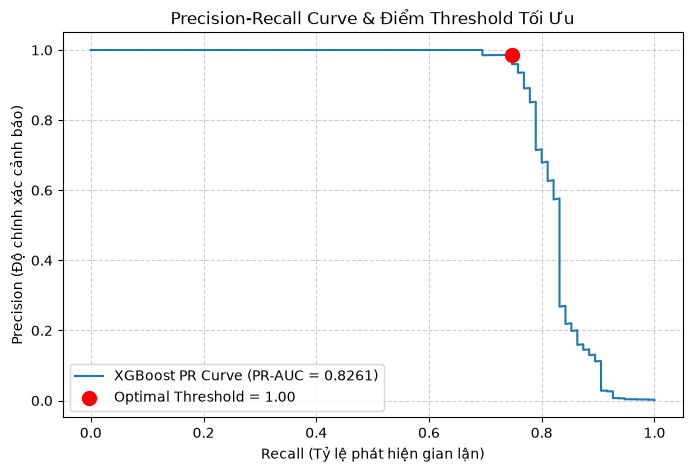

In [10]:
# Tính diện tích dưới đường cong PR (PR-AUC)
pr_auc = auc(recalls, precisions)

plt.figure(figsize=(8, 5))
plt.plot(
    recalls, precisions, label=f"XGBoost PR Curve (PR-AUC = {pr_auc:.4f})"
)
# Đánh dấu điểm Threshold tối ưu lên biểu đồ
plt.scatter(
    best_recall,
    best_precision,
    color="red",
    s=100,
    zorder=5,
    label=f"Optimal Threshold = {optimal_threshold:.2f}",
)

plt.xlabel("Recall (Tỷ lệ phát hiện gian lận)")
plt.ylabel("Precision (Độ chính xác cảnh báo)")
plt.title("Precision-Recall Curve & Điểm Threshold Tối Ưu")
plt.legend(loc="lower left")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

# 4. Xuất Model Artifacts

In [11]:
# Nạp lại 2 Scaler từ bước tiền xử lý
scaler_amount = joblib.load("scaler_amount.pkl")
scaler_time = joblib.load("scaler_time.pkl")

# Gom tất cả vào 1 Dictionary
artifact = {
    "model": best_xgb_model,
    "optimal_threshold": optimal_threshold,
    "scaler_amount": scaler_amount,
    "scaler_time": scaler_time,
}

# Lưu thành file hoàn chỉnh
joblib.dump(artifact, "fraud_detection_pipeline.joblib")

['fraud_detection_pipeline.joblib']